# Test Neo4j Text2Cypher Workflow

This notebook tests the LangGraph workflow incrementally, adding one node at a time.

In [1]:
# Import dependencies
from neo4j_agent.agent import create_text2cypher_workflow
from neo4j_agent.utils.config import AppSettings
from neo4j_agent.utils.history import get_conversation_history

In [2]:
# Load configuration (env vars + YAML for UI settings)
settings = AppSettings.from_yaml("app-config/config.yml")
print(f"LLM Provider: {settings.llm.provider}")
print(f"LLM Model: {settings.llm.model}")
print(f"Neo4j URI: {settings.neo4j.uri}")
print(f"Neo4j Database: {settings.neo4j.database}")
print(f"UI Title: {settings.ui.title}")
print(f"Scope: {settings.ui.scope_description}")
print("Configuration loaded successfully!")

LLM Provider: openai
LLM Model: gpt-4o
Neo4j URI: bolt://localhost:7687
Neo4j Database: honda
UI Title: IQS Data Explorer
Scope: This application may answer questions related to customer feedback on Honda vehicles.
Configuration loaded successfully!


In [3]:
# Create the Text2Cypher workflow (connects to Neo4j, loads schema, builds graph)
print("Creating Text2Cypher workflow...")
app = create_text2cypher_workflow(settings)
print("Workflow created successfully!")

Creating Text2Cypher workflow...
Loaded schema from cache: app-config\neo4j_schema\honda_schema.json
Workflow created successfully!


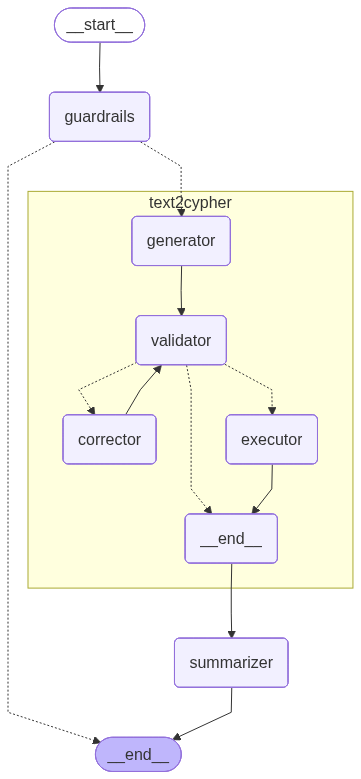

In [4]:
# View with xray parameter to expand subgraphs
from IPython.display import Image, display

try:
    # Try with xray=True to expand nested subgraphs
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print("Main graph (xray view):")
    print(app.get_graph(xray=True).draw_ascii())

In [5]:
def ask_question(question: str, thread_id: str = "user-session-1"):
    """Ask a question to the Text2Cypher agent.
    
    Uses combined streaming modes ["custom", "values"] to capture both neo4j_result 
    and complete accumulated state in a SINGLE workflow execution.
    
    Args:
        question: Natural language question
        thread_id: Session ID (same thread = conversation history preserved)
        
    Returns:
        Tuple of (final_state, neo4j_result)
    """
    print(f"\n{'='*90}")
    print(f"Q: {question}")
    print(f"{'='*90}")
    
    initial_state = {
        "question": question,
        "retry_count": 0,
    }
    
    config = {"configurable": {"thread_id": thread_id}}
    
    # Capture BOTH neo4j_result (custom) and complete state (values) in SINGLE execution
    neo4j_result = None
    final_state = None
    
    # Use multiple stream modes: returns 3-tuples of (namespace, mode, data)
    for chunk in app.stream(initial_state, config, stream_mode=["custom", "values"], subgraphs=True):
        namespace, mode, data = chunk
        
        if mode == "custom":
            # Custom stream from executor
            if isinstance(data, dict) and "neo4j_result" in data:
                neo4j_result = data["neo4j_result"]
        
        elif mode == "values":
            # Complete accumulated state after each node - track the final one
            if not namespace:  # Main workflow (not subgraph)
                final_state = data
    
    # Display results
    if final_state and final_state.get('error'):
        print(f"❌ Error: {final_state['error']}")
        retry_count = final_state.get('retry_count', 0)
        if retry_count > 0:
            print(f"   Correction attempts: {retry_count}")
    elif final_state:
        print(f"✅ Workflow completed successfully")
        
        # Show the generated Cypher query
        if final_state.get('cypher_query'):
            print(f"\n📝 Generated Cypher:")
            print(f"   {final_state['cypher_query']}")
        
        # Show record count
        if final_state.get('query_results') is not None:
            record_count = len(final_state['query_results'])
            print(f"\n📊 Query Results: {record_count} records")
            if record_count > 0:
                print(f"   First record: {final_state['query_results'][0]}")
        
        # Show the natural language answer
        if final_state.get('final_answer'):
            print(f"\n💬 Answer:")
            print(f"   {final_state['final_answer']}")
    
    print(f"{'='*90}")
    
    return final_state, neo4j_result

print("✅ Helper function fixed - using 'values' stream mode for complete state!")

✅ Helper function fixed - using 'values' stream mode for complete state!


In [6]:
# Test multiple questions in the same session

# Valid question
result1 = ask_question("What's the weather like today?")

# Invalid question
result2 = ask_question("What are Honda Civic problems related to doors?")

# Another valid question (entities from schema)
result3 = ask_question("What about Acura Integra?")


Q: What's the weather like today?
❌ Error: Question is out of scope for this system. Please ask questions about data in the graph database.

Q: What are Honda Civic problems related to doors?
✅ Workflow completed successfully

📝 Generated Cypher:
   MATCH (v:Verbatim {make: "Honda", model: "Civic"})-[:HAS_PROBLEM]->(p:Problem)
WHERE v.verbatimText CONTAINS 'door'
RETURN p.problem AS problem
LIMIT 50

📊 Query Results: 50 records
   First record: {'problem': 'SEAT23: Seat materials scuff/soil easily'}

💬 Answer:
   Honda Civic problems related to doors include:

1. Doors - Hard to open/close
2. Doors - Handle/latch/release - DTU
3. Doors - Squeak/abnormal noise when opening/closing
4. Water leaks into vehicle

Q: What about Acura Integra?
✅ Workflow completed successfully

📝 Generated Cypher:
   MATCH (v:Verbatim {make: "Acura", model: "Integra"})-[:HAS_PROBLEM]->(p:Problem)
WHERE v.verbatimText CONTAINS 'door'
RETURN p.problem AS problem
LIMIT 50

📊 Query Results: 50 records
   First r

In [ ]:
def ask_question_with_detailed_progress(question: str, thread_id: str = "user-session-2"):
    """Show detailed progress including subgraph nodes in correct order."""
    
    print(f"\nQ: {question}\n{'='*60}")
    
    initial_state = {"question": question, "retry_count": 0}
    config = {"configurable": {"thread_id": thread_id}}
    
    neo4j_result = None
    final_state = None
    pending_main_node = None
    subgraph_steps = []  # Buffer subgraph steps
    
    for chunk in app.stream(initial_state, config, stream_mode=["custom", "updates", "values"], subgraphs=True):
        namespace, mode, data = chunk
        
        if mode == "custom":
            if isinstance(data, dict) and "neo4j_result" in data:
                neo4j_result = data["neo4j_result"]
        
        elif mode == "updates":
            # Subgraph nodes (namespace is a tuple with content)
            if namespace:
                for node_name, _ in data.items():
                    subgraph_steps.append(node_name)  # Buffer the subgraph step
            
            # Main workflow nodes (namespace is empty tuple)
            else:
                for node_name, _ in data.items():
                    # Print any pending main node first
                    if pending_main_node:
                        print(f"✓ {pending_main_node.replace('_', ' ').title()}")
                        pending_main_node = None
                    
                    # If this is text2cypher and we have buffered subgraph steps, print them
                    if node_name == "text2cypher" and subgraph_steps:
                        print(f"✓ {node_name.replace('_', ' ').title()}")
                        for step in subgraph_steps:
                            print(f"  └─ {step.replace('_', ' ').title()}")
                        subgraph_steps = []  # Clear buffer
                    else:
                        # For non-subgraph nodes, just buffer
                        pending_main_node = node_name
        
        elif mode == "values":
            if not namespace:
                final_state = data
    
    # Print any remaining buffered node
    if pending_main_node:
        print(f"✓ {pending_main_node.replace('_', ' ').title()}")
    
    print("="*60)
    
    # Display results
    if final_state:
        if final_state.get('error'):
            print(f"\n❌ {final_state['error']}")
        elif final_state.get('final_answer'):
            print(f"\n💬 Answer:\n{final_state['final_answer']}")
            if final_state.get('cypher_query'):
                print(f"\n📝 Cypher:\n{final_state['cypher_query']}")
    
    return final_state, neo4j_result

In [13]:
# Test multiple questions in the same session

# Valid question
result1 = ask_question_with_detailed_progress("What's the weather like today?")

# Invalid question
result2 = ask_question_with_detailed_progress("What are Honda Civic problems related to doors?")

# Another valid question (entities from schema)
result3 = ask_question_with_detailed_progress("What about Acura Integra?")


Q: What's the weather like today?
DEBUG: namespace=(), data keys=['guardrails']
✓ Guardrails

❌ Question is out of scope for this system. Please ask questions about data in the graph database.

Q: What are Honda Civic problems related to doors?
DEBUG: namespace=(), data keys=['guardrails']
DEBUG: namespace=('text2cypher:b0a1979e-3eb2-fc70-288f-281f8a001590',), data keys=['generator']
✓ Guardrails
  └─ Generator
DEBUG: namespace=('text2cypher:b0a1979e-3eb2-fc70-288f-281f8a001590',), data keys=['validator']
  └─ Validator
DEBUG: namespace=('text2cypher:b0a1979e-3eb2-fc70-288f-281f8a001590',), data keys=['executor']
  └─ Executor
DEBUG: namespace=(), data keys=['text2cypher']
DEBUG: namespace=(), data keys=['summarizer']
✓ Text2Cypher
✓ Summarizer

💬 Answer:
Honda Civic problems related to doors include:

- Door panels - Squeak/rattle/other noise
- Doors - Hard to open/close
- Doors - Handle/latch/release - DTU
- Doors - Squeak/abnormal noise when opening/closing

📝 Cypher:
MATCH (v:Verb

In [9]:
def show_session_history(thread_id: str = "user-session-1"):
    """Show the conversation history for a thread using our history utility."""
    config = {"configurable": {"thread_id": thread_id}}
    
    print(f"\n{'='*60}")
    print(f"📊 Session History: {thread_id}")
    print(f"{'='*60}")
    
    # Get all checkpoints for total count
    all_checkpoints = list(app.get_state_history(config))
    print(f"Total checkpoints saved: {len(all_checkpoints)}")

    # Get the checkpointer from the app
    checkpointer = app.checkpointer
    
    # Get conversation history (only successful questions with cypher)
    history = get_conversation_history(checkpointer, config, max_history=50, include_answers=False)
    
    if history:
        print(f"\n📝 Successful Q&A pairs in this session:")
        for idx, pair in enumerate(reversed(history), 1):  # Newest first
            question = pair['question']
            cypher = pair['cypher_query']
            
            # Truncate long queries for display
            cypher_display = cypher if len(cypher) <= 80 else cypher[:77] + "..."
            
            print(f"  {idx}. ✅ {question}")
            print(f"     Cypher: {cypher_display}")
    
    # Show rejected questions separately
    rejected = []
    questions_seen = set(pair['question'] for pair in history)
    
    for checkpoint in all_checkpoints:
        question = checkpoint.values.get('question')
        error = checkpoint.values.get('error')
        
        if question and error and question not in questions_seen:
            rejected.append(question)
            questions_seen.add(question)
    
    if rejected:
        print(f"\n❌ Rejected questions:")
        for idx, question in enumerate(reversed(rejected), 1):
            print(f"  {idx}. {question}")
    
    print(f"{'='*60}\n")

show_session_history()


📊 Session History: user-session-1
Total checkpoints saved: 26

📝 Successful Q&A pairs in this session:
  1. ✅ What about Acura Integra?
     Cypher: MATCH (v:Verbatim {make: "Acura", model: "Integra"})-[:HAS_PROBLEM]->(p:Probl...
  2. ✅ What are Honda Civic problems related to doors?
     Cypher: MATCH (v:Verbatim {make: "Honda", model: "Civic"})-[:HAS_PROBLEM]->(p:Problem...
  3. ✅ What's the weather like today?
     Cypher: MATCH (v:Verbatim {make: "Acura", model: "Integra"})-[:HAS_PROBLEM]->(p:Probl...

